<a href="https://colab.research.google.com/github/solosolve-ai/solosolve-ai/blob/main/SFT_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# STEP 1: INSTALL LIBRARIES
# ==============================================================================
print("--> Step 1: Installing required libraries...")
!pip install -q pandas "scipy>=1.10.0" plotly kaleido duckdb
print("--> Libraries installed successfully.")


# ==============================================================================
# STEP 2: IMPORT LIBRARIES
# ==============================================================================
print("\n--> Step 2: Importing libraries...")
from google.colab import drive
import pandas as pd
import duckdb
from IPython.display import display
print("--> Libraries imported successfully.")


# ==============================================================================
# STEP 3: MOUNT GOOGLE DRIVE
# ==============================================================================
print("\n--> Step 3: Mounting Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    print("--> Google Drive mounted successfully!")
except Exception as e:
    print(f"--> An error occurred while mounting Google Drive: {e}")


# ==============================================================================
# STEP 4: SETUP AND POPULATE THE DUCKDB DATABASE (Corrected Workflow)
# ==============================================================================
print("\n--> Step 4: Setting up and populating the DuckDB database...")

# --- Connect to an in-memory DuckDB database ---
con = duckdb.connect(database=':memory:', read_only=False)
print("    - DuckDB connection established.")

# --- Drop the table if it exists to ensure a clean start ---
con.execute("DROP TABLE IF EXISTS reviews;")

# --- **KEY FIX**: Define the CREATE TABLE statement with the FULL 14-column schema ---
create_full_schema_sql = """
CREATE TABLE reviews (
    rating FLOAT,
    text VARCHAR,
    asin VARCHAR,
    parent_asin VARCHAR,
    user_id VARCHAR,
    timestamp BIGINT,
    product_title VARCHAR,
    average_rating FLOAT,
    rating_number INTEGER,
    features VARCHAR,
    description VARCHAR,
    price FLOAT,
    store VARCHAR,
    details VARCHAR
);
"""
con.execute(create_full_schema_sql)
print("    - 'reviews' table created with the correct 14-column schema.")

# --- Load and Clean data using the robust Pandas method ---
file_path = '/content/drive/MyDrive/cleaned_amazon_fashion_data.csv'
print(f"    - Loading and cleaning data from '{file_path}'...")
try:
    # Read the CSV with flexible settings
    df = pd.read_csv(
        file_path,
        encoding='latin-1',
        engine='python',
        on_bad_lines='skip'
    )

    # Clean the crucial numeric columns, turning errors into missing values (NaN)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
    df['rating_number'] = pd.to_numeric(df['rating_number'], errors='coerce')
    df['average_rating'] = pd.to_numeric(df['average_rating'], errors='coerce')

    # Drop rows where 'rating' is invalid, as it's essential for analysis
    initial_rows = len(df)
    df.dropna(subset=['rating'], inplace=True)
    rows_dropped = initial_rows - len(df)
    print(f"    - Data types cleaned. Dropped {rows_dropped} rows with invalid ratings.")

    # Insert the full, cleaned DataFrame into the DuckDB table
    con.execute("INSERT INTO reviews SELECT * FROM df;")
    print("    - Data successfully inserted into DuckDB.")

    # --- Drop the 'description' column FROM THE DATABASE as requested ---
    con.execute("ALTER TABLE reviews DROP COLUMN description;")
    print("    - 'description' column dropped from the database table.")

    print("\n✅ SETUP COMPLETE: Database is ready for analysis.")

except Exception as e:
    print(f"❌ An error occurred during the data loading process: {e}")

--> Step 1: Installing required libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.9 MB/s eta 0:00:00
--> Libraries installed successfully.

--> Step 2: Importing libraries...
--> Libraries imported successfully.

--> Step 3: Mounting Google Drive...
Mounted at /content/drive
--> Google Drive mounted successfully!

--> Step 4: Setting up and populating the DuckDB database...
    - DuckDB connection established.
    - 'reviews' table created with the correct 14-column schema.
    - Loading and cleaning data from '/content/drive/MyDrive/cleaned_amazon_fashion_data.csv'...
    - Data types cleaned. Dropped 73 rows with invalid ratings.
    - Data successfully inserted into DuckDB.
    - 'description' column dropped from the database table.

✅ SETUP COMPLETE: Database is ready for analysis.

--> Step 5: Verifying the final state of the 'reviews' table in the database...

Final Table Schema:
┌

--- 1. Visualizing Top 10 Most Reviewed Products ---



--- 2. Visualizing Distribution of Ratings ---



--- 3. Visualizing Distribution of Prices (< $200) ---



--- 4. Statistical Test: Price Difference for 1 vs 2-Star Ratings ---
Independent Samples T-test Results:
  T-statistic: -1.2807
  P-value: 0.2003

Interpretation: The difference in the mean price between 1-star and 2-star rated products is not statistically significant (p >= 0.05).

--- 5. Visualizing Complaint Volume Over Time ---



--- 6. Generating Word Cloud from Review Text ---


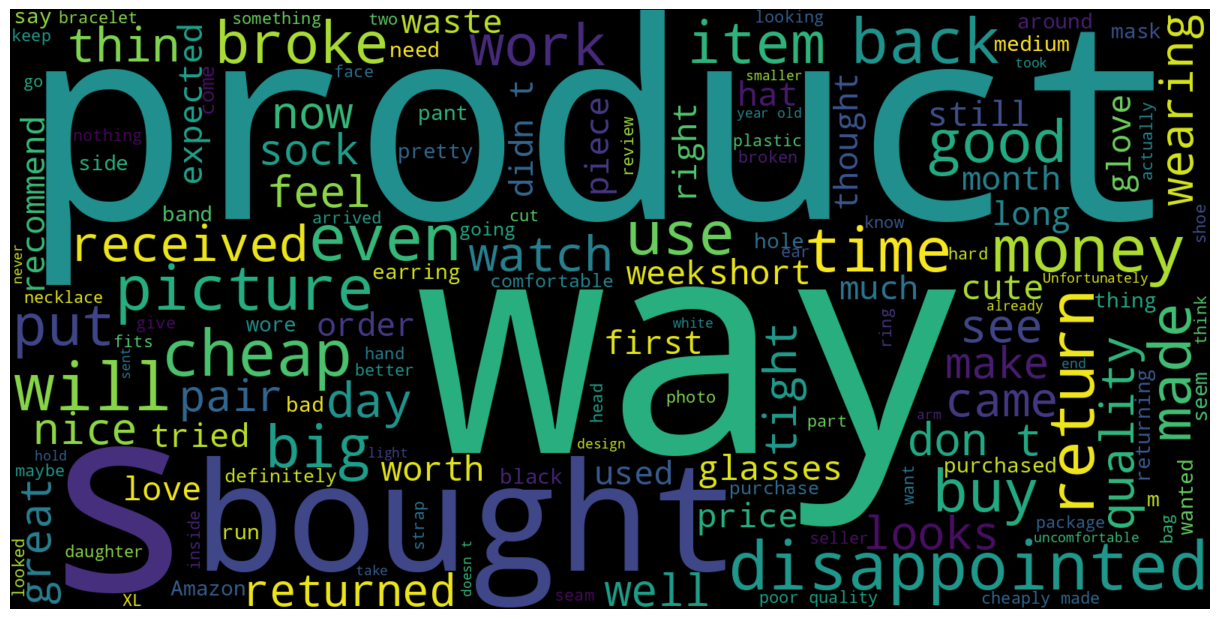

In [4]:
# ==============================================================================
# VISUALIZATION AND ANALYSIS CELL
# All data is sourced directly from the DuckDB database.
# ==============================================================================

import pandas as pd
import plotly.express as px
from scipy import stats
# Libraries needed for the new Word Cloud visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# This code assumes your DuckDB connection 'con' is active from the previous cell.

# --- 1. Top 10 Products by Review Count ---
print("--- 1. Visualizing Top 10 Most Reviewed Products ---")
top_10_query = """
    SELECT
        product_title,
        COUNT(*) as review_count
    FROM reviews
    GROUP BY product_title
    ORDER BY review_count DESC
    LIMIT 10;
"""
top_10_df = con.sql(top_10_query).df()
fig_top10 = px.bar(top_10_df,
                   x='review_count',
                   y='product_title',
                   orientation='h',
                   title='Top 10 Products by Number of 1 & 2-Star Reviews',
                   labels={'review_count': 'Number of Reviews', 'product_title': 'Product Title'},
                   template='plotly_dark',
                   text='review_count')
fig_top10.update_layout(yaxis={'categoryorder':'total ascending'})
fig_top10.show()


# --- 2. Distribution of Ratings ---
print("\n--- 2. Visualizing Distribution of Ratings ---")
ratings_query = "SELECT rating FROM reviews WHERE rating IS NOT NULL;"
ratings_df = con.sql(ratings_query).df()
fig_rating = px.histogram(ratings_df, x="rating", title="Distribution of Ratings",
                          template="plotly_dark", text_auto=True)
fig_rating.update_layout(bargap=0.2)
fig_rating.show()


# --- 3. Distribution of Prices (< $200) ---
print("\n--- 3. Visualizing Distribution of Prices (< $200) ---")
price_query = "SELECT price FROM reviews WHERE price < 200 AND price IS NOT NULL;"
prices_df = con.sql(price_query).df()
fig_price = px.histogram(prices_df, x="price", title="Distribution of Prices (< $200)",
                         template="plotly_dark", nbins=50)
fig_price.show()


# --- 4. T-test for Price Difference Between 1 & 2-Star Ratings ---
print("\n--- 4. Statistical Test: Price Difference for 1 vs 2-Star Ratings ---")
ttest_query = "SELECT rating, price FROM reviews WHERE rating IN (1, 2) AND price IS NOT NULL;"
ttest_df = con.sql(ttest_query).df()
prices_r1 = ttest_df[ttest_df['rating'] == 1]['price']
prices_r2 = ttest_df[ttest_df['rating'] == 2]['price']
t_stat, p_value = stats.ttest_ind(prices_r1, prices_r2, equal_var=False, nan_policy='omit')
print(f"Independent Samples T-test Results:")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.4f}")
alpha = 0.05
if p_value < alpha:
    print("\nInterpretation: The difference in the mean price between 1-star and 2-star rated products is statistically significant (p < 0.05).")
else:
    print("\nInterpretation: The difference in the mean price between 1-star and 2-star rated products is not statistically significant (p >= 0.05).")


# --- 5. Complaint Volume Over Time ---
print("\n--- 5. Visualizing Complaint Volume Over Time ---")
monthly_query = """
    SELECT
        DATE_TRUNC('month', to_timestamp(timestamp / 1000)) AS month,
        COUNT(*) AS complaint_count
    FROM reviews
    GROUP BY month
    ORDER BY month;
"""
monthly_counts_df = con.sql(monthly_query).df()
if not monthly_counts_df.empty:
    fig_monthly_volume = px.line(monthly_counts_df, x="month", y="complaint_count",
                                 title="Monthly Complaint Volume (1 and 2-star Reviews)",
                                 template="plotly_dark", markers=True,
                                 labels={"month": "Month", "complaint_count": "Complaint Count"})
    fig_monthly_volume.show()
else:
    print("No data available to plot monthly complaint volume.")


# --- 6. Word Cloud of Review Text ---
print("\n--- 6. Generating Word Cloud from Review Text ---")
# Query to get all review texts from DuckDB
text_query = "SELECT text FROM reviews WHERE text IS NOT NULL;"
text_df = con.sql(text_query).df()

# Join all the review texts into a single large string
all_text = " ".join(review for review in text_df['text'])

# Define a set of stopwords: start with the default and add custom words
# common to fashion reviews to get more meaningful results.
stopwords = set(STOPWORDS)
stopwords.update(["br", "size", "wear", "fit", "color", "look", "like", "fabric",
                  "material", "shirt", "dress", "top", "ordered", "got", "one",
                  "would", "really", "small", "large", "little"])

# Create the WordCloud object with desired styling
wordcloud = WordCloud(width=1600, height=800,
                      background_color='black',
                      stopwords=stopwords,
                      max_words=150,
                      colormap='viridis',
                      min_font_size=10).generate(all_text)

# Display the generated image using matplotlib
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()